# Машинное обучение, ШАД
## Лабораторная работа 3. Линейные модели классификации и регрессии, валидация моделей.


**Правила:**

* Выполненную работу нужно отправить в соответствующее задание в личном кабинете
* Дедлайн **10 октября 15:00**. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Для сдачи задания нужно загрузить **ноутбук в формате `ipynb`** в ЛМС.
* Выполнять задание необходимо полностью самостоятельно.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Присылайте понятный и читаемый код. Если код не будет понятен проверяющему, оценка может быть снижена.
* Код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * прикрепив ее в ЛМС в форматах `pdf`, `png` или `jpg` *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image`;
  * в виде $\LaTeX$ в markdown-ячейках или в отдельном `pdf`-файле.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 1 балл;
* Задача 2 &mdash; 1 балл;
* Задача 3 &mdash; 1 балл;
* Задача 4 &mdash; 1 балл;
* Задача 5 &mdash; 5 баллов.

----

---
### Задача 1. 

1. Пусть $X_1,...,X_n$ &mdash; выборка из гамма-распределения с плотностью $p_\theta(x) = \frac{\theta^\beta}{\Gamma(\beta)} x^{\beta-1} e^{-\theta x}$, где $\theta>0, \beta>0, x>0$, причем $\beta$ известно. Найдите оценку максимального правдоподобия параметра $\theta$.

2. Пусть $X_1,...,X_n$ &mdash; выборка из пуассоновского распределения, для которого $\mathsf{P}_\theta(X_i = k) = \frac{\theta^k}{k!}e^{-\theta}$, где $\theta>0, k \in \mathbb{Z}_+ = \{0, 1, 2, ...\}$. Найдите оценку максимального правдоподобия параметра $\theta$.

#### Решение

1. $X_1,...,X_n \sim \text{iid}\;\Gamma(\beta,\,\theta)$. Найдем ОМП параметра $\theta>0$ при известном $\beta>0$; $X_i > 0,\; i=\overline{1,\,n}$

    Обозначим $\mathbf{x} = \begin{pmatrix}x_1,...,x_n\end{pmatrix}^\mathsf{T}$ Функция правдоподобия:

    $L_\theta(\mathbf{x}) = \prod\limits_{i=1}^n p_\theta(x_i)$.

    Логарифмическая функция правдоподобия: 

    $ l_\theta(\mathbf{x}) = \ln(L_\theta(\mathbf{x})) = \sum\limits_{i=1}^n \ln(p_\theta(x_i)) = n\beta \ln(\theta) + (\beta - 1) \sum\limits_{i=1}^n \ln(x_i) - \theta \sum\limits_{i=1}^n x_i - n \ln(\Gamma(\beta))$.

    Найдем ОМП параметра $\theta$, для этого максимизируем $l_\theta(x)$ (эквивалентно максимизации $L_\theta(x)$ из-за монотонности логарифма):

    $\hat{\theta} = \underset{\theta}{\text{argmax}}\;l_\theta(\mathbf{x})$.

    $\dfrac{\partial l_\theta(\mathbf{x})}{\partial \theta} = \dfrac{n \beta}{\theta} - \sum\limits_{i=1}^n x_i = 0 \implies \hat{\theta} = \dfrac{n \beta}{\sum\limits_{i=1}^n x_i}; \quad \dfrac{\partial^2 l_\theta(\mathbf{x})}{\partial \theta^2} = -\dfrac{n\beta}{\theta^2} < 0$

    По второй производной видим, что функция выпукла на области определения. Таким образом, находим ОМП $\hat{\theta}$:

    $\hat{\theta} = \dfrac{n \beta}{\sum\limits_{i=1}^n x_i} = \dfrac{\beta}{\overline{x}},$ где $\overline{x} = \dfrac{1}{n}\sum\limits_{i=1}^n x_i$ - среднее по выборке


2. $X_1,...,X_n \sim \text{iid}\; \text{Pois}(\theta)$. Найдем ОМП параметра $\theta>0$; $X_i\in\mathbb{Z}_+$.

    Обозначим $\mathbf{x} = \begin{pmatrix}x_1,...,x_n\end{pmatrix}^\mathsf{T}$ Функция правдоподобия:

    $L_\theta(\mathbf{x}) = \prod\limits_{i=1}^n \mathsf{P}_\theta(x_i)$.

    Логарифмическая функция правдоподобия: 

    $ l_\theta(\mathbf{x}) = \ln(L_\theta(\mathbf{x})) = \sum\limits_{i=1}^n \ln(x_i) = - n\theta + \ln(\theta)\left(\sum\limits_{i=1}^n x_i\right) - \sum\limits_{i=1}^n \ln(x_i!)$

    $\hat{\theta} = \underset{\theta}{\text{argmax}}\;l_\theta(\mathbf{x})$.

    $\dfrac{\partial l_\theta(\mathbf{x})}{\partial \theta} = -n + \dfrac{1}{\theta}\sum\limits_{i=1}^n x_i = 0 \implies \hat{\theta} = \dfrac{1}{n}\sum\limits_{i=1}^n x_i = \overline{x}; \quad \dfrac{\partial^2 l_\theta(\mathbf{x})}{\partial \theta^2} = -\dfrac{1}{\theta^2}\sum\limits_{i=1}^n x_i \leqslant 0.$

    По второй производной можно видеть, что в стационарной точке она неотрицательна и равна нулю только при $x_i=0,\;\forall i$. Таким образом, находим ОМП $\hat{\theta}$:

    $\hat{\theta} = \overline{x}$.

---
### Задача 2.

Пусть $\ell_Y(\theta)$ &mdash; логарифмическая функция правдоподобия в модели логистической регрессии, задачу максимизации которой мы рассматривали на лекции. Добавим к ней $L_2$-регуляризатор и будем рассматривать задачу
$$F(\theta) = -\ell_Y(\theta) + \lambda \|\theta\|^2  \longrightarrow \min_{\theta \in \mathbb{R}^d},$$
где $\lambda > 0$ &mdash; коэффициент регуляризации.

1. Выпишите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

2. Покажите, что $F(\theta)$ &mdash; выпуклая функция по $\theta$ и, как следствие, имеет единственный экстремум, являющийся глобальным максимумом. *Указание*. Посчитайте гессиан (матрицу вторых производных) и покажите, что она положительно определена.

3. Опишите, как может вести себя решение при отсутствии регуляризации, то есть при $\lambda = 0$

#### Решение

Рассмотрим модель логистической регрессии с метками классов $y_i \in \{-1,\, 1\}$. Размер выборки равен $n$, число признаков равно $d$, $n > d$. Будем также считать, что свободного члена нет.

$ \mathsf{P}(y_i = 1 | \mathbf{x}_i) = \sigma(\theta^\mathsf{T}\mathbf{x}_i) $;

$ \mathsf{P}(y_i = -1 | \mathbf{x}_i) = 1 - \sigma(\theta^\mathsf{T}\mathbf{x}_i) $.

Можно объединить две формулы в одну:

$ \mathsf{P}(y_i | \mathbf{x}_i) = \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i),\; M_i = y_i\theta^\mathsf{T}\mathbf{x}_i  \text{ --- margin} $

Запишем логарифмическую формулу правдоподобия. Для того, чтобы выражение меньше зависело от размера выборки (по порядку), разделим на ее размер $n$:

$l_\theta(\mathbf{X},\mathbf{y}) = \dfrac{1}{n}\sum\limits_{i=1}^n \ln(\sigma(y_i\theta^\mathsf{T}\mathbf{x}_i)) = - \dfrac{1}{n}\sum\limits_{i=1}^n \ln(1 + e^{-y_i\theta^\mathsf{T}\mathbf{x}_i}) = l(\theta)$

Таким образом, $L_2$-регуляризованная версия логарифмической функции правдоподобия будет иметь вид:

$F(\theta) = -l(\theta) + R(\theta) = \dfrac{1}{n} \sum\limits_{i=1}^n \ln(1 + e^{-y_i\theta^\mathsf{T}\mathbf{x}_i}) + \lambda\|\theta\|^2_2$.

1. Найдем градиент $l(\theta)$ и $R(\theta)$:

    $\dfrac{\partial l(\theta)}{\partial \theta_j} = \dfrac{1}{n} \sum\limits_{i=1}^n \dfrac{y_i x_{ij} e^{-y_i \theta^\mathsf{T}\mathbf{x}_i}}{1 + e^{-y_i\theta^\mathsf{T}\mathbf{x}_i}} = \dfrac{1}{n} \sum\limits_{i=1}^n y_i x_{ij} \left( 1 - \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i) \right);\quad \nabla l(\theta) = \dfrac{1}{n} \mathbf{X}^\mathsf{T} (\mathbf{v}(\theta) \odot \mathbf{y})$, 

    где $\mathbf{v}(\theta) = ( 1 - \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i))_{i=1}^n),\; \mathbf{y} \in \mathbb{R}^n$, а $\mathbf{X}\in \mathbb{R}^{n\times d}$ - матрица объект-признак.

    $\dfrac{\partial R(\theta)}{\partial \theta_j} = 2 \lambda \theta_j;\quad\nabla R(\theta) = 2\lambda\theta$.

    Таким образом, $\nabla F(\theta) = \nabla l(\theta) + \nabla R(\theta) $.  $\nabla F(\theta) = 0$ не имеет аналитического решения, поэтому воспользуемся оптимизацией. 

    Выпишем формулы GD и SGD:

    * GD:

        $\theta_{k+1} = \theta_k - \alpha \nabla F(\theta) = \theta_k - \alpha \left(\dfrac{1}{n} \mathbf{X}^\mathsf{T} (\mathbf{v}(\theta) \odot \mathbf{y}) + 2\lambda\theta \right)$

    * SGD: 
        
        Выражение аналогичное, только для шага оптимизации выбирается подмножество элементов размера $m$ выборки размера $n$ 
        
        (иногда именно вариант с $m=1$ называют SGD): 

        $\theta_{k+1} = \theta_k - \alpha \left(\dfrac{1}{m} \mathbf{X}_b^\mathsf{T} (\mathbf{v}_b(\theta) \odot \mathbf{y}_b) + 2\lambda\theta \right)$,

        где $\mathbf{v}_b(\theta),\mathbf{y}_b \in \mathbb{R}^m$, $\mathbf{X}_b\in \mathbb{R}^{m\times d}$

2. Найдем гессиан $l(\theta)$ и $R(\theta)$:
   
    $\dfrac{\partial^2 l(\theta)}{\partial \theta_k \partial \theta_j} = \sum\limits_{i=1}^n y_i^2 x_{ij} x_{ik} \dfrac{e^{-y_i\theta^\mathsf{T}\mathbf{x}_i}}{(1+e^{-y_i\theta^\mathsf{T}\mathbf{x}_i})^2} = \sum\limits_{i=1}^n x_{ij} x_{ik} \dfrac{e^{-y_i\theta^\mathsf{T}\mathbf{x}_i}}{(1+e^{-y_i\theta^\mathsf{T}\mathbf{x}_i})^2} = \sum\limits_{i=1}^n x_{ij} x_{ik}  \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i) (1- \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i))$.

    Формула может быть переписана в виде:

    $\nabla^2 l(\theta) = \mathbf{X}^\mathsf{T} \mathbf{D} \mathbf{X}$, где $\mathbf{D} = \text{diag}((\sigma(y_i\theta^\mathsf{T}\mathbf{x}_i) (1- \sigma(y_i\theta^\mathsf{T}\mathbf{x}_i)))_{i=1}^n)$.

    Гессиан регуляризационного слагаемого:

    $\dfrac{\partial^2 R(\theta)}{\partial \theta_k \partial \theta_j} = 2\lambda \delta_{jk}$

    Перепишем в векторной форме:

    $ \nabla^2 R(\theta) = 2\lambda \mathbf{I}$.

    Гессиан функции потерь:

    $ \nabla^2 F(\theta) = \mathbf{X}^\mathsf{T} \mathbf{D} \mathbf{X} + 2\lambda \mathbf{I}$

    Из того факта, что $\sigma(y_i\theta^\mathsf{T}\mathbf{x}_i)\in(0;1),\;\forall i\; \forall\mathbf{x}_i,y_i$, следует положительность чисел на диагонали матрицы $\mathbf{D}$. Поэтому можно извлечь из нее корень: $\mathbf{D} = \mathbf{D}^{1/2} \mathbf{D}^{1/2} = (\mathbf{D}^{1/2})^\mathsf{T} \mathbf{D}^{1/2}$.

    Исследуем определенность гессиана $\nabla^2 F(\theta)$. Рассмотрим $\mathbf{z}\neq0$:

    $\mathbf{z}^\mathsf{T} \nabla^2 F(\theta) \mathbf{z} = \mathbf{z}^\mathsf{T} \left(\mathbf{X}^\mathsf{T} \mathbf{D} \mathbf{X} + 2\lambda \mathbf{I} \right) \mathbf{z} = \|\mathbf{D}^{1/2} \mathbf{X} \mathbf{z}\|^2_2 + 2\lambda \| \mathbf{z} \|^2_2 > 0$.

    Заметим, что даже если $\mathbf{X}$ не имеет полного ранга, второе слагаемое всегда будет гарантировать положительную определенность при  $\lambda > 0$. Таким образом, функция $F(\theta)$ является выпуклой, поэтому если у функции будет экстремум, то он будет глобальным минимумом.

 3. Регуляризация отсутствует ($\lambda = 0$). Могут возникнуть как минимум две проблемы (при этом возникнуть они могут одновременно):
   
    * В случае, если $\mathbf{X}$ не имеет полный ранг (то есть признаки (столбцы) линейно независимы), то из этого следует, что уравнение $\mathbf{X}\mathbf{z} = 0$ имеет ненулевое решение $\tilde{\mathbf{z}}\neq0$ (имеет нетривиальное ядро). Тогда для $\tilde{\mathbf{z}}\neq 0$ из ядра $\mathbf{X}$:

        $\tilde{\mathbf{z}}^\mathsf{T} \nabla^2 F(\theta) \tilde{\mathbf{z}} = \|\mathbf{D}^{1/2} \mathbf{X} \tilde{\mathbf{z}}\|^2_2 = 0$.

        Поэтому, не изменяя величину $F(\theta) = F(\theta')$, можно добиваться решений с нормой, стремящейся к бесконечности:

        $\theta'^\mathsf{T} \mathbf{x} = (\theta + \beta \tilde{\mathbf{z}})^\mathsf{T} \mathbf{x} = \theta^\mathsf{T}\mathbf{x}$, $\| \theta' \|^2_2 \rightarrow \infty$. 

        Это негативно сказывается на устойчивости решения, на вычислительную точность.

    * Проблема в логистической регрессии без регуляризации также возникает при условии, что выборка линейно разделима.

        Действительно, рассмотрим выборку $(\mathbf{x}_i,y_i)_{i=1}^n$, для которой существует гиперплоскость задаваемая параметром $\theta = \theta_0$, разделяющая классы c метками $y=-1$ и $y=1$:

        $y_i \theta_0^\mathsf{T} \mathbf{x}_i > 0,\; \forall i$.

        Возьмем $\gamma>0$ и рассмотрим $\theta_\gamma = \gamma \theta_0$. Уравнение самой плоскости в этом случае не изменяется (и полупространтсва, относящиеся к каждому из двух классов). Подставим параметр в функцию потерь:

        $ F(\theta_\gamma) = -l(\theta_\gamma) = \dfrac{1}{n} \sum\limits_{i=1}^n \ln(1 + e^{-y_i\gamma\theta^\mathsf{T}\mathbf{x}_i}) $.

        Тогда при $\gamma \rightarrow \infty$ выполняется $\|\theta_\gamma \|^2_2 \rightarrow \infty$, при этом $F(\theta_\gamma) \rightarrow 0$, не достигая инфинума, равного нулю, для любых конечных элементов вектора $\theta_\gamma$. Таким образом, вектор параметров также может иметь неограниченно большие по модулю коэффициенты.







---
### Задача 3.

Рассмотрим линейную регрессию $y(x) = x^T \theta$, причем для оценки $\theta$ будем рассматривать функцию потерь Хьюбера
$$R(x) = \frac{x^2}{2} I\{|x| \leqslant c\} + c\left(|x| - \frac{c}{2}\right)I\{|x| > c\}.$$

Тем самым задача оптимизации имеет вид
$$\sum_{i=1}^n R(Y_i - x_i^T \theta) \longrightarrow \min_{\theta \in \mathbb{R}^d}.$$

1. Нарисуйте график $R(x)$. В чем польза выбора такой функции потерь?

2. Выпишите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

#### Решение

1. Функция Хьюбера.

    Функция Хьюбера позволяет объединить преимущества MAE и MSE: с одной стороны, данная функция менее подвержена влиянию выбросов в сравнении с MSE, так как вне $B_c(0)$ совпадает с MAE (меньше штрафует выбросы), с другой стороны, в $B_c(0)$ данная функция совпадает с MSE, то есть является сильно выпуклой (а это увеличивает скорость сходимости оптимизационных методов).

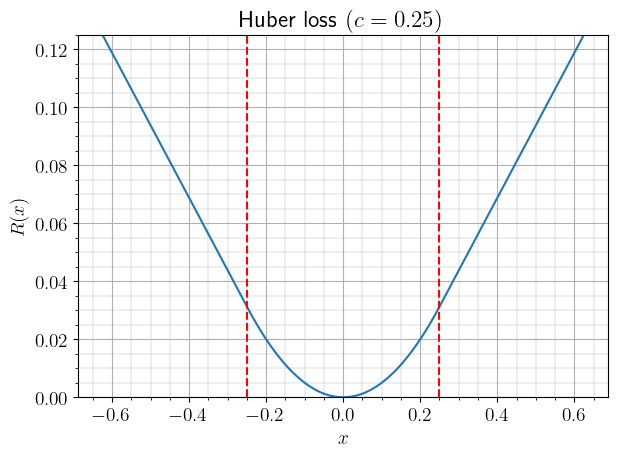

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'text.usetex' : True, 'font.size' : 14})

c = 0.25
x_huber = np.linspace(-2.5*c, 2.5*c, 1000)
c_mask = (np.abs(x_huber) <= c)
y_huber = 0.5 * x_huber**2 * c_mask + c * (np.abs(x_huber) - 0.5 * c) * ~c_mask

plt.figure()
plt.plot(x_huber, y_huber)
plt.vlines(x=c, ymin=0, ymax=y_huber.max(), color='r', ls='--')
plt.vlines(x=-c, ymin=0, ymax=y_huber.max(), color='r', ls='--')
plt.ylim([0, y_huber.max()]); plt.minorticks_on(); plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3)
plt.xlabel(r'$x$'); plt.ylabel(r'$R(x)$'); plt.title('Huber loss $(c=0.25)$')
plt.tight_layout()

2. Выпишем формулы GD и SGD

    Производная функции Хьюбера имеет вид:

    $R'(x) = \begin{cases} x,\; &|x|\leqslant c\\ c \cdot \text{sign}(x),\; &|x| > c\end {cases}$.

    Введем векторную функцию векторного аргумента $r(\mathbf{x})$ (поэлементное применение к вектору функции Хьюбера):

    $(r(\mathbf{x}))_i = R(x_i)$.

    $\dfrac{\partial r(\mathbf{x})}{\partial x_i} = \begin{cases} x_i,\; &|x_i|\leqslant c\\ c \cdot \text{sign}(x_i),\; &|x_i| > c\end {cases}$

    Обозначим $L(\theta) = \dfrac{1}{n}\sum\limits_{i=1}^n R(y_i - \mathbf{x}_i^\mathsf{T} \theta) $. Вычислим градиент:

    $\dfrac{\partial L(\theta)}{\partial \theta_j} = - \dfrac{1}{n} \sum\limits_{i=1}^n x_{ij} \nabla R(y_i - \mathbf{x}_i^\mathsf{T} \theta)$

    $\nabla L(\theta) = - \dfrac{1}{n} \mathbf{X}^\mathsf{T} \nabla r(\mathbf{y} - \mathbf{X}\theta) $

    * GD:
    
        $\theta_{k+1} = \theta_k - \alpha \nabla L(\theta);\quad \theta_{k+1} = \theta_k + \alpha \dfrac{1}{n} \mathbf{X}^\mathsf{T} \nabla r(\mathbf{y} - \mathbf{X}\theta)$ 

    * SGD 
        
        Выражение аналогичное, только для шага оптимизации выбирается подмножество элементов размера $m$ выборки размера $n$ 
        
        (иногда именно вариант с $m=1$ называют SGD): :

        $\theta_{k+1} = \theta_k + \alpha \dfrac{1}{m} \mathbf{X}_b^\mathsf{T} \nabla r(\mathbf{y}_b - \mathbf{X}_b\theta)$, 

        где $\mathbf{y}_b \in \mathbb{R}^m$, $\mathbf{X}_b\in \mathbb{R}^{m\times d}$

---
### Задача 4.

В предыдущем домашнем задании вы подробно познакомились с линейными моделями, выяснили о необходимости обработки непрерывных и категориальных 

признаков, узнали о способах подбора гиперпараметров. Порассуждайте над следующими вопросами.

**1.** Какие побочные эффекты могут возникунуть при стандартизации (нормализации) признаков с помощью `StandardScaler`, `MinMaxScaler`? Что с этим можно сделать?

**2.** Рассмотрим пример с первого занятия про модель потребления мороженного от температуры:
$$ic=\theta_1 + \theta_2 t.$$
Предположим, что нам также известен еще один признак, отвечающий за год. Обозначим его за $y$. Пусть $y \in \{1, 2, 3\}$. Попробуем учесть влияние года двумя разными способами:
* Модель $ic = \theta_1 + \theta_2 t+ \theta_3 y_1 + \theta_4 y_2$, где $y_1 = I\{y=1\}$, $y_2 = I\{y=2\}$.
* Для каждого года рассматривается своя линейная зависимость $ic=\theta_1+\theta_2 t$.
  
Поясните, в чем различие этих двух подходов.

**3.** Визуализируйте совместные распределения вещественных признаков и целевой переменной для данных из предыдущего домашнего задания. Что можно сказать о зависимости таргета от признаков? Сделайте вывод о том, насколько хорошо построенные модели приближают истинные зависимости. 

Полученные графики приложите к решению теоретического задания.

**Условие непонятно (вырвано из контекста), после обсуждения в чате решили не учитывать данный пункт (4.3)**

#### Решение

1. Рассмотрим побочные эффекты методов нормировки признаков:
   *  `StandardScaler`
        Побочные эффекты:

        * Выбросы могут значительно сместить среднее и увеличить стандартное отклонение, что может привести к неправильной нормализации всей выборки в целом.
        * В случае сильно ассиметричного распределения (например, экспоненциального) стандартизация не будет интерпретируемой. В целом, стандартизация предполагает, что распределение близко к нормальному (что часто бывает справедливо для реальных непрерывных данных).

   *  `MinMaxScaler`
        Побочные эффекты:

        * Если данные содержат выбросы, максимальное и минимальное значение могут быть соответственно значительно завышено или занижено, что негативно повлияет на масштабирование всей выборки.
        * Данный метод более подходит для распределений, похожих на равномерное, в частности имеющих ограниченный носитель (или малую вероятность получения значений за пределами некоторого диапазона). Данные, имеющие неравномерное распределение, могут быть сжаты в одном конце диапазона, что может ухудшить качество модели.
  
    Возможные решения:

    Можно предварительно обработать данные, убрав выбросы или применяя логарифмическое (и другие подобные) преобразование. Хорошей идеей может быть проведение статистических тестов для каждого признака (или хотя бы визуальный анализ) и проводить нормализацию на основе знания о распределении данных.



2. Рассматриваются две модели:

   1. **Первая модель**: одинаковая зависимость от температуры, разные уровни базового потребления (разные свободные члены)


        $ic = \theta_1 + \theta_2 t + \theta_3 y_1 + \theta_4 y_2$,

        где $y_1 = I\{y=1\}$ и $y_2 = I\{y=2\}$ — индикаторные переменные для годов 1 и 2 соответственно.
        
        Эта модель предполагает, что зависимость между температурой и потреблением одинакова для всех годов, однако учитываются разные уровни потребления в зависимости от года.

        Параметры имеют следующий смысл:
        - $\theta_1$: базовый уровень потребления в год 3 (так как для него не используется индикатор).
        - $\theta_2$: влияние температуры на потребление (линейный коэффициент зависимости от температуры, общий для всех годов).
        - $\theta_3$: изменение базового уровня потребления в год 1 относительно года 3.
        - $\theta_4$: изменение базового уровня потребления в год 2 относительно года 3.

        Общее число параметров: 4

    2.  **Вторая модель**: предполагает наличие отдельных линейных зависимостей для каждого года

        $ic = 
        \begin{cases} 
        \theta_{1,1} + \theta_{2,1} t, & \text{если } y = 1 \\
        \theta_{1,2} + \theta_{2,2} t, & \text{если } y = 2 \\
        \theta_{1,3} + \theta_{2,3} t, & \text{если } y = 3 
        \end{cases}$

        Параметры имеют следующий смысл: каждый год имеет свои собственные коэффициенты $\theta_{1,j}$ (свободный член) и $\theta_{2,j}$ (линейный коэффициент зависимости от температуры), данная модель позволяет учитывать различное влияние температуры на потребление для каждого года.

        Общее число параметров: 6



3. **Условие непонятно (вырвано из контекста), после обсуждения в чате решили не учитывать данный пункт (4.3)**


---
### Задача 5.

Реализуйте логистическую регрессию с $L_2$ регуляризацией для поиска оценки параметров с помощью стохастического mini-batch градиентного спуска (SGD).

В данном задании рассмотрим вариант с классами 0 и 1

In [2]:
import numpy as np
import scipy as sp
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import RegressorMixin
from numpy import ndarray
from tqdm import tqdm

np.random.seed(0)

In [3]:
class LogisticRegression(RegressorMixin):
    '''
    Модель логистической регрессии с регуляризацией.
    
    :param alpha: параметр регуляризации (L2).
                  Если равно 0, то регуляризация отсутствует.
    :param lr: коэффициент скорости обучения
    :param max_iter: максимальное количество итераций
    :param fit_intercept: указывает, следует ли добавить константу (свободный член)
    :param batch_size: размер мини-батча для SGD
    '''
    def __init__(self, 
                 alpha: float = 0.0, 
                 lr: float = 1e-2, 
                 max_iter: int = 1000, 
                 fit_intercept: bool = True,
                 batch_size: int = 64) -> None:
        self.alpha = alpha
        self.lr = lr
        self.max_iter = int(max_iter)
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size

    @staticmethod
    def _sigmoid(x: ndarray) -> ndarray:
        return sp.special.expit(x)

    def _add_intercept(self, X: ndarray) -> ndarray:
        return np.hstack([X, np.ones((X.shape[0], 1))])

    def fit(self, X: ndarray, y: ndarray):
        '''
        Обучает модель логистической регрессии с помощью SGD.
        
        :param X: матрица признаков
        :param y: истинные метки классов
        '''
        if self.fit_intercept:
            X = self._add_intercept(X)
        
        n, d = X.shape
        self.weights = np.zeros(d)

        for _ in range(self.max_iter):
            ids = np.random.choice(n, size=self.batch_size, replace=False)
            X_batch = X[ids]
            y_batch = y[ids]

            predictions = self._sigmoid(X_batch @ self.weights)
            errors = predictions - y_batch

            grad = (X_batch.T @ errors) / self.batch_size


            if self.fit_intercept:
                grad[:-1] += self.alpha * self.weights[:-1] 
            else:
                grad += self.alpha * self.weights

            self.weights -= self.lr * grad

        self.coef_ = self.weights[:-1] if self.fit_intercept else self.weights
        self.intercept_ = self.weights[-1:] if self.fit_intercept else None

    def predict_proba(self, X: ndarray) -> ndarray:
        '''
        Возвращает вероятность принадлежности классу 1.
        
        :param X: матрица признаков
        :return: массив вероятностей принадлежности классу 1
        '''
        if self.fit_intercept:
            X = self._add_intercept(X)

        prob = self._sigmoid(X @ self.weights)
        return np.stack([1 - prob, prob], axis=-1)

    def predict(self, X: ndarray) -> ndarray:
        '''
        Предсказывает метки классов.
        
        :param X: матрица признаков
        :return: массив предсказанных меток классов
        '''
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)
    
    def get_params(self, deep: bool = True) -> dict: 
        params =  {
            'alpha' : self.alpha, 
            'lr' : self.lr,
            'max_iter' : self.max_iter,
            'fit_intercept' : self.fit_intercept, 
            'batch_size' : self.batch_size
        }
        return params
    
    def set_params(self, **parameters):
        for param, val in parameters.items():
            setattr(self, param, val)
        return self

Рассмотрим игрушечный датасет на $30$ признаков `load_breast_cancer` из библиотеки `sklearn`. Это относительно простой для бинарной классификации датасет по диагностике рака молочной железы.

Ради интереса можно прочитать описание признаков.

In [4]:
dataset = load_breast_cancer()
dataset['DESCR'].split('\n')[11:31]

[':Attribute Information:',
 '    - radius (mean of distances from center to points on the perimeter)',
 '    - texture (standard deviation of gray-scale values)',
 '    - perimeter',
 '    - area',
 '    - smoothness (local variation in radius lengths)',
 '    - compactness (perimeter^2 / area - 1.0)',
 '    - concavity (severity of concave portions of the contour)',
 '    - concave points (number of concave portions of the contour)',
 '    - symmetry',
 '    - fractal dimension ("coastline approximation" - 1)',
 '',
 '    The mean, standard error, and "worst" or largest (mean of the three',
 '    worst/largest values) of these features were computed for each image,',
 '    resulting in 30 features.  For instance, field 0 is Mean Radius, field',
 '    10 is Radius SE, field 20 is Worst Radius.',
 '',
 '    - class:',
 '            - WDBC-Malignant',
 '            - WDBC-Benign']

Разделим нашу выборку на обучающую и тестовую:

In [5]:
X, Y = dataset['data'], dataset['target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((455, 30), (114, 30), (455,), (114,))

При использовании регуляризации данные необходимо нормализовать. Воспользуемся для этого классом `StandardScaler` из библиотеки `sklearn`. 

In [6]:
logreg_pipeline = Pipeline([
    ('std_scaler', StandardScaler()), 
    ('logreg', LogisticRegression(alpha=0.1, lr=1e-2, max_iter=10000, batch_size=64, fit_intercept=True))
])

Теперь обучите модель логистической регрессии.

In [7]:
logreg_pipeline.fit(X_train, Y_train)
Y_pred = logreg_pipeline.predict(X_test)

In [8]:
logreg_pipeline['logreg'].coef_, logreg_pipeline['logreg'].intercept_

(array([-2.62759138e-01, -2.59797532e-01, -2.59006699e-01, -2.45049738e-01,
        -1.12096260e-01, -8.73015933e-02, -2.08653232e-01, -2.85073988e-01,
        -7.13217772e-02,  1.11437728e-01, -2.17793366e-01,  1.35862419e-02,
        -1.74345718e-01, -1.79047322e-01,  2.15934045e-04,  7.93522798e-02,
         4.35653290e-02, -6.66518065e-02,  6.88561947e-02,  1.27602370e-01,
        -3.08683182e-01, -3.27189720e-01, -2.91591239e-01, -2.70977009e-01,
        -2.25947424e-01, -1.56526255e-01, -2.30970644e-01, -3.06133333e-01,
        -2.53246833e-01, -8.29250151e-02]),
 array([0.65798659]))

На занятии обсуждали, что в нашей постановке задачи при сравнении выиграет модель с меньшим FN, ведь каждая не обнаруженная опухоль может стоить человеческой жизни. Чем меньше ложно отрицательных срабатываний, тем выше Recall модели, а значит разумно взять Recall в качестве целевой метрики. 

Построить модель с Recall = 1 довольно просто (Как?), но в ней не будет большого смысла, т.к., например, для нашей задачи отправление на доп. обследование может стоить дополнительных средств и времени специалистов, поэтому хотелось, чтобы наша модель имела неплохую точность. Какую метрику можно использовать, чтобы учесть и точность, и полноту?

Выберите и посчитайте целевые метрики для нашей задачи.

Вырожденная модель с Recall = 1 - это классификатор, всегда предсказывающий положительный класс. Однако для Precision будет равен отнощению размеров классов, а Precision и Recall относительно другого класса будут равны 0.

Простая метрика, учитывающая Precision и Recall - f1-метрика, являющаяся средним геометрическим этих величин:

$\text{F1} = 2\dfrac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$.

Данная метрика является средним (в том смысле, что она лежит между двумя величинами, не превосходя максимум и не бывая меньше минимума). Кроме того, если хотя бы одна из двух метрик мала, то $\text{F1} $ похожа на максимум, а при примерно равных значениях - на среднее.

В качестве итоговой метрики выберем среднюю между классами f1-метрику (macro average).

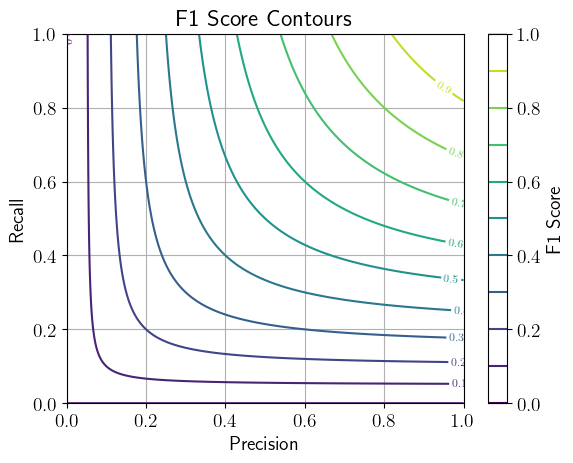

In [9]:
precision = np.linspace(0, 1, 1000)
recall = np.linspace(0, 1, 1000)

P, R = np.meshgrid(precision, recall)

F1 = 2 * (P * R) / (P + R + 1e-12) 

plt.figure()
contour = plt.contour(P, R, F1, levels=np.linspace(0, 1, 11))
plt.clabel(contour, inline=True, fontsize=8)
plt.colorbar(label='F1 Score')
plt.title('F1 Score Contours')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.show()

In [10]:
def clf_metrics(Y_test, Y_pred, cls=0):
    TP = np.sum(Y_test[Y_test==cls] == Y_pred[Y_test==cls])
    # TN = np.sum(Y_test[Y_test==1-cls] == Y_pred[Y_test==1-cls])
    FP = np.sum(Y_test[Y_test==1-cls] != Y_pred[Y_test==1-cls])
    FN = np.sum(Y_test[Y_test==cls] != Y_pred[Y_test==cls])
    precision = TP/(TP+FP + 1e-12)
    recall = TP/(TP+FN + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    
    return precision, recall, f1

In [11]:
def clf_avg_f1(Y_test, Y_pred):
    f1_0 = clf_metrics(Y_test, Y_pred, 0)[2]
    f1_1 = clf_metrics(Y_test, Y_pred, 1)[2]
    
    f1_avg = 0.5 * (f1_0 + f1_1)
    
    return f1_avg

In [12]:
precision_0, recall_0, f1_0 = clf_metrics(Y_test, Y_pred, cls=0)
print(f'{precision_0 = :.3f}; {recall_0 = :.3f}; {f1_0 = :.3f}')

precision_1, recall_1, f1_1 = clf_metrics(Y_test, Y_pred, cls=1)
print(f'{precision_1 = :.3f}; {recall_1 = :.3f}; {f1_1 = :.3f}')

f1_avg = clf_avg_f1(Y_test, Y_pred)
print(f'macro avg f1 = {f1_avg:.3f}')

precision_0 = 1.000; recall_0 = 0.930; f1_0 = 0.964
precision_1 = 0.959; recall_1 = 1.000; f1_1 = 0.979
macro avg f1 = 0.972


Сравним с библиотечной реализацией:

In [13]:
print(classification_report(y_true=Y_test, y_pred=Y_pred, digits=3))

              precision    recall  f1-score   support

           0      1.000     0.930     0.964        43
           1      0.959     1.000     0.979        71

    accuracy                          0.974       114
   macro avg      0.980     0.965     0.972       114
weighted avg      0.975     0.974     0.973       114



Рассмотрите как влияет размер шага (`learning rate`) на качество модели. Обучите каждую модель одинаковое число итераций (например, 10000), а затем посчитайте качество. Сделайте выводы.

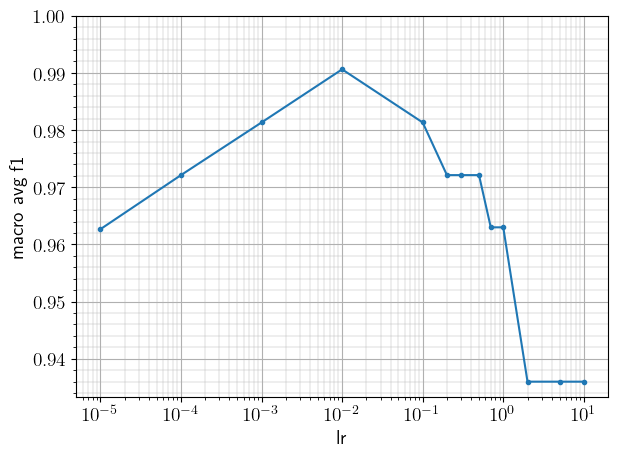

In [14]:
lrs = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.3, 0.5, 0.7, 1, 2, 5, 10]

f1_list_lrs = []

for lr in tqdm(lrs, leave=False):
    logreg_pipeline_lr = Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(lr=lr, max_iter=10000))
    ])
    
    logreg_pipeline_lr.fit(X_train, Y_train)
    Y_pred_lr = logreg_pipeline_lr.predict(X_test)
    f1_list_lrs.append(clf_avg_f1(Y_test, Y_pred_lr))
    
plt.figure()
plt.semilogx(lrs, f1_list_lrs, marker='.')
plt.ylim([None, 1]); plt.minorticks_on(); plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3)
plt.xlabel(r'lr'); plt.ylabel(r'macro avg f1')
plt.tight_layout()

Из графика можно видеть, что при росте `lr`, при $10^{-2}$, метрика достигает наибольших значений. При дальнейшем росте `lr` метрика сильно падает. При малых `lr` градиентный спуск не успевает сойтись (может потребоваться увеличение чисшла шагов), а при больших не попадает в минимум из-за большого шага.

Рассмотрите несколько моделей, в которых установите не менее 5-ти различных коэффициентов регуляризации, а также модель без регуляризатора. Сравните, влияет ли наличие регуляризации на качество, сделайте выводы. Под качеством подразумевается значение какой-либо выбранной вами метрики качества классификации.

macro avg f1 (alpha=0) = 0.981


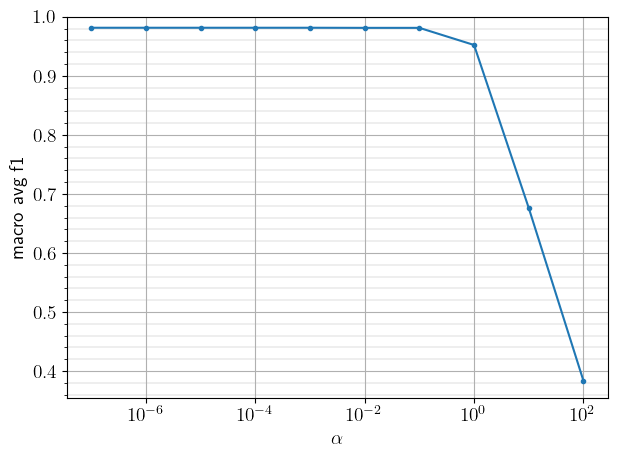

In [15]:
alphas = np.append(np.logspace(-7, 2, 10, base=10), 0)

f1_list_alphas = []

for alpha in tqdm(alphas, leave=False):
    logreg_pipeline_alphas = Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(alpha=alpha, lr=1e-2, max_iter=10000))
    ])
    logreg_pipeline_alphas.fit(X_train, Y_train)
    Y_pred_alphas = logreg_pipeline_alphas.predict(X_test)
    f1_list_alphas.append(clf_avg_f1(Y_test, Y_pred_alphas))
    
plt.figure()
plt.semilogx(alphas[:-1], f1_list_alphas[:-1], marker='.')
plt.ylim([None, 1]); plt.minorticks_on(); plt.grid(True, 'major'); plt.grid(True, 'minor', lw=0.3)
plt.xlabel(r'$\alpha$'); plt.ylabel(r'macro avg f1')
plt.tight_layout()

print(f'macro avg f1 (alpha=0) = {f1_list_alphas[-1]:.3f}')

Можно видеть, что наличие регуляризации улучшает качество модели. Коэффициент регуляризации можно выбирать в пределах $10^{-7} - 10^{-1}$

Выберите наилучшее значение коэффициента регуляризации с помощью кросс-валидации для двух подходов &mdash; `KFold` и `ShuffleSplit`. Используйте пять фолдов/разбиений.

In [16]:
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, RepeatedKFold
from sklearn.metrics import make_scorer

gs_kfold = GridSearchCV(
    estimator=Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(alpha=alpha, lr=1e-2, max_iter=10000))
    ]), 
    param_grid={'logreg__alpha' : alphas}, 
    scoring=make_scorer(clf_avg_f1),
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    verbose=0
)

gs_kfold.fit(X=X_train, y=Y_train)
lr_gs_kfold = gs_kfold.best_estimator_

In [17]:
gs_kfold.best_score_, gs_kfold.best_params_

(np.float64(0.9737570284117174), {'logreg__alpha': np.float64(0.01)})

In [18]:
gs_shuffle_split = GridSearchCV(
    estimator=Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(alpha=alpha, lr=1e-2, max_iter=10000))
    ]),  
    param_grid={'logreg__alpha' : alphas}, 
    scoring=make_scorer(clf_avg_f1),
    cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
    n_jobs=-1,
    verbose=0
)
gs_shuffle_split.fit(X=X_train, y=Y_train)
lr_gs_shuffle_split = gs_shuffle_split.best_estimator_

In [19]:
gs_shuffle_split.best_score_, gs_shuffle_split.best_params_

(np.float64(0.9737885310641733), {'logreg__alpha': np.float64(0.01)})

In [20]:
alpha = gs_kfold.best_params_['logreg__alpha'] if gs_kfold.best_score_ > gs_shuffle_split.best_score_ else gs_shuffle_split.best_params_['logreg__alpha'] 
print(f'alpha = {float(alpha)}')

alpha = 0.01


Лучшим коэффициентом регуляризации оказался $\alpha=10^{-2}$ для обоих методов валидации.

Для выбранного значения коэффициента регуляризации оцените дисперсию усредненного значения метрики качества на тестовых батчах. Для этого выполните кросс-валидацию достаточно много раз (не менее 100) и посчитайте выборочную дисперсию. Обратите внимание, что для стратегии `KFold` нужно на каждой итерации перемешивать данные, для этого можно указать `shuffle=True`.

Сравните эти две стратегии кросс-валидации. Какие их преимущества и недостатки?

In [21]:
n_repeats = 100
n_splits = 5

In [22]:
kfold = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=0)
f1_kfold = []

for (train_index, test_index) in tqdm(kfold.split(X_train), leave=False):
    logreg_kfold = Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(alpha=alpha, max_iter=10000))
    ])
    logreg_kfold.fit(X_train[train_index], Y_train[train_index])
    Y_pred_kfold = logreg_kfold.predict(X_train[test_index])
    f1_kfold.append(clf_avg_f1(Y_test=Y_train[test_index], Y_pred=Y_pred_kfold))    
    
f1_kfold = np.array(f1_kfold)

In [23]:
var_f1_kfold = float(f1_kfold.var(ddof=1))
print(f'{var_f1_kfold = :.5f}')

var_f1_kfold = 0.00024


In [24]:
shuffle_split = ShuffleSplit(n_splits=n_splits * n_repeats, test_size=0.2, random_state=0)
f1_shuffle_split = []

for (train_index, test_index) in tqdm(shuffle_split.split(X_train), leave=False):
    logreg_shuffle_split = Pipeline([
        ('std_scaler', StandardScaler()), 
        ('logreg', LogisticRegression(alpha=alpha, max_iter=10000))
    ])
    logreg_shuffle_split.fit(X_train[train_index], Y_train[train_index])
    Y_pred_shuffle_split = logreg_shuffle_split.predict(X_train[test_index])
    f1_shuffle_split.append(clf_avg_f1(Y_test=Y_train[test_index], Y_pred=Y_pred_shuffle_split))    
    
f1_shuffle_split = np.array(f1_shuffle_split)

In [25]:
var_f1_shuffle_split = float(f1_shuffle_split.var(ddof=1))
print(f'{var_f1_shuffle_split = :.5f}')

var_f1_shuffle_split = 0.00028


**Вывод:** 

Приведем таблицу с основными особенностями двух методов кросс-валидации: KFold и ShuffleSplit:

| **Характеристика**                | **KFold**                                                   | **ShuffleSplit**                                             |
|---------------------------|------------------------------------------------------------|-------------------------------------------------------------|
| **Метод разбиения**   | Делит набор данных на $ k $ равных частей (фолдов), использует по очереди 1 для тестирования и $k-1$ для обучения   | Случайным образом перемешивает и делит данные на обучающую и тестовую выборки. |
| **Покрытие данных**       | Каждый элемент используется ровно один раз в тестовой выборке.  | Некоторые элементы могут попадать в тестовый набор несколько раз; другие могут никогда не использоваться. |
| **Пересечения между выборками** | Нет пересечений; разные тестовые наборы для каждого фолда.  | Возможны пересечения в тестовых наборах из-за случайности.   |
| **Вычислительная сложность**| Выше при больших значениях $ k $ (требуется обучение модели $ k $ раз) | Обычно ниже (при выборе меньшего числа разбиений); обучение можно проводить на меньших выборках за одну итерацию, есть возможность не покрывать всю выборку |
| **Контроль над размерами выборок** | Фиксированное соотношение для обучающих и тестовых наборов (например, 80/20). | Можно задавать независимые размеры для обучающей и тестовой выборок, в том числе суммарно меньше размера выборки |
| **Работа с большими выборками** | Менее эффективно для больших наборов данных из-за повторного обучения. | Более эффективно; позволяет быстро оценивать на больших наборах данных. |
| **Дисперсия**             | Обычно имеет более низкую дисперсию в оценках производительности благодаря обходу всей выборки (при большой вычислительной сложности) | Может иметь более высокую дисперсию из-за случайности разбиения, что приводит к менее стабильным оценкам качества. |
| **Область применения** | Полная валидация для выборок малого и среднего размеров. | Более быстрая оценка, гибкое разбиение для больших выборок. |

Для сбалансированности классов при разбиении предпочтительнее использовать `stratified`-версии данных методов.
